In [1]:
%load_ext autoreload
%autoreload 2

# Trade Strategy 20250603

## Description
Combine various individual strategies and assets to create a portfolio.

## Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from utils.data_fetcher import TickerPriceDataFetcher
import os
from indicators.volatility import calculate_atr, calculate_forward_vol
from indicators.returns import calculate_returns, calculate_forward_returns, calculate_MA_returns, calculate_relative_volume
from utils.helpers import PercentileScaler
import datetime
from sklearn.linear_model import LinearRegression
from utils.backtester import BackTester
import backtrader as bt
from sklearn.metrics import r2_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from pypfopt.hierarchical_portfolio import HRPOpt
from pypfopt.plotting import plot_dendrogram
from pypfopt import risk_models
from scipy import stats
from scipy.stats import linregress



Warning - Certain functionality 
             requires requests_html, which is not installed.
             
             Install using: 
             pip install requests_html
             
             After installation, you may have to restart your Python session.


c:\Users\alexr\AlgoTester\utils\data_fetcher.py:19: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


## Utils

### Helpers

In [3]:
def normalize_weights(weights):
    total_weight = sum(weights.values())
    normalized_weights = {ticker: weight / total_weight for ticker, weight in weights.items()}
    return normalized_weights

def gmean(arr):
    return np.exp(np.mean(np.log(arr)))

def hmean(arr):
    return 1 / np.mean(1 / arr)


def compute_r2(y):
    x = range(len(y))
    result = linregress(x, y)
    r_squared = result.rvalue ** 2
    return r_squared

## Parameters

In [4]:
lookforward_period = 50
lookback_periods=[21, 50, 100, 200, 252]

rebalance_period = 21
atr_period = 21
covariance_matrix_lookback = 252
historical_lookback_period = 252 * 2
vol_target = 0.1
current_date = datetime.datetime.now().date()
current_date = current_date.strftime("%Y%m%d")

tickers_to_fetch = ['IB01.L', 'SHV', 'SPY', 'TLT', 'GLD', '^VIX', '^GVZ', 'PPLT', 'URA', 'DBA', 'EEM', 'LQD', 'IBIT', 'USO']
tickers_to_trade = [
    'SPY', 
    # 'TLT', 
    'GLD', 
    # '^VIX', 
    # '^GVZ', 
    'PPLT', 
    'URA', 
    'DBA', 
    'EEM', 
    'LQD', 
    'IBIT', 
    'USO'
]

## Load Data

In [5]:
fetcher = TickerPriceDataFetcher()
price_data = fetcher.load_data(ticker_list=tickers_to_fetch)

for ticker in price_data:
    print(ticker, price_data[ticker].index.to_list()[0], price_data[ticker].index.to_list()[-1])
    # display(price_data[ticker])


2025-07-13 16:19:04,824 - utils.data_fetcher - INFO - Loading data for ['IB01.L', 'SHV', 'SPY', 'TLT', 'GLD', '^VIX', '^GVZ', 'PPLT', 'URA', 'DBA', 'EEM', 'LQD', 'IBIT', 'USO']
2025-07-13 16:19:04,824 - utils.data_fetcher - INFO - Data for IB01.L already exists
2025-07-13 16:19:04,826 - utils.data_fetcher - INFO - Data for SHV already exists
2025-07-13 16:19:04,827 - utils.data_fetcher - INFO - Data for SPY already exists
2025-07-13 16:19:04,829 - utils.data_fetcher - INFO - Data for TLT already exists
2025-07-13 16:19:04,830 - utils.data_fetcher - INFO - Data for GLD already exists
2025-07-13 16:19:04,831 - utils.data_fetcher - INFO - Data for ^VIX already exists
2025-07-13 16:19:04,833 - utils.data_fetcher - INFO - Data for ^GVZ already exists
2025-07-13 16:19:04,834 - utils.data_fetcher - INFO - Data for PPLT already exists
2025-07-13 16:19:04,835 - utils.data_fetcher - INFO - Data for URA already exists
2025-07-13 16:19:04,836 - utils.data_fetcher - INFO - Data for DBA already exis

IB01.L 2019-02-20 00:00:00 2025-07-11 00:00:00
SHV 2007-01-11 00:00:00 2025-07-11 00:00:00
SPY 1993-01-29 00:00:00 2025-07-11 00:00:00
TLT 2002-07-30 00:00:00 2025-07-11 00:00:00
GLD 2004-11-18 00:00:00 2025-07-11 00:00:00
^VIX 1990-01-02 00:00:00 2025-07-11 00:00:00
^GVZ 2008-06-03 00:00:00 2025-07-11 00:00:00
PPLT 2010-01-08 00:00:00 2025-07-11 00:00:00
URA 2010-11-05 00:00:00 2025-07-11 00:00:00
DBA 2007-01-05 00:00:00 2025-07-11 00:00:00
EEM 2003-04-14 00:00:00 2025-07-11 00:00:00
LQD 2002-07-30 00:00:00 2025-07-11 00:00:00
IBIT 2024-01-11 00:00:00 2025-07-11 00:00:00
USO 2006-04-10 00:00:00 2025-07-11 00:00:00


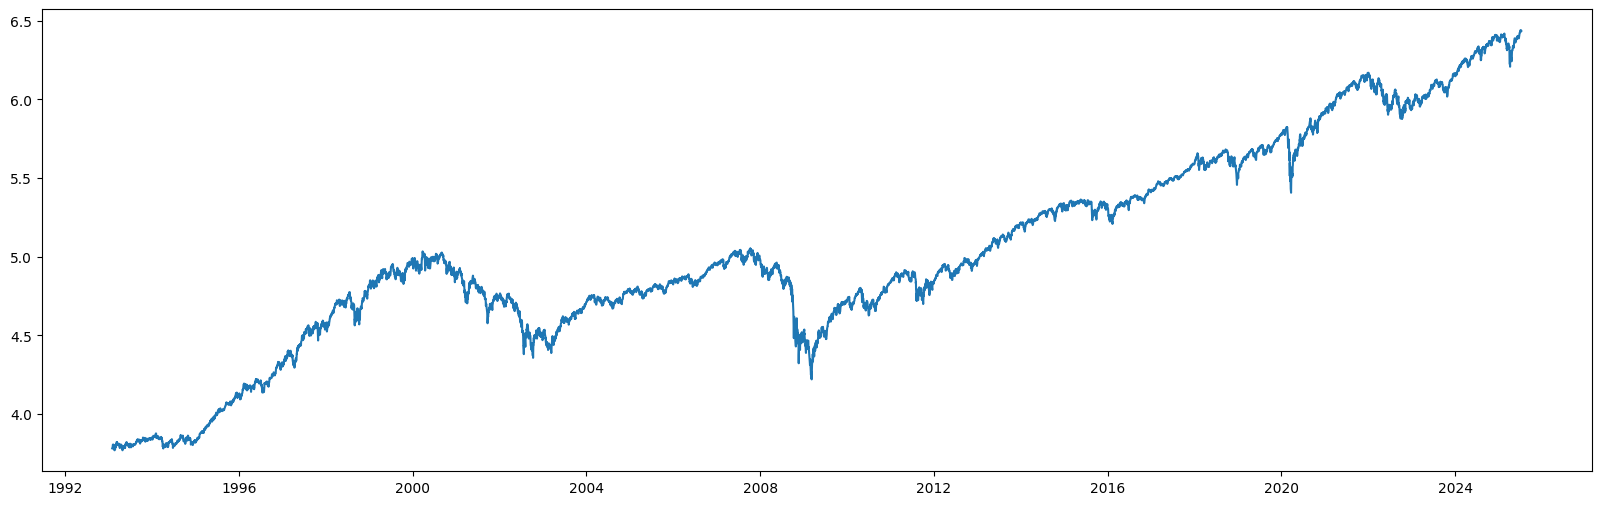

In [6]:
df = price_data['SPY'].copy()
df['log_close'] = np.log(df['close'])

plt.figure(figsize=(20, 6))
plt.plot(df['log_close'])
plt.show()

## Process Data

In [7]:
def process_price_data(df, lookforward_period=21, atr_period=21, lookback_periods=[21, 100, 200, 252], vix_ticker=None):
    # Calculate indicators
    df['returns'] = df['close'].pct_change()
    df['vol_forward'] = calculate_forward_vol(df, lookforward_period)
    df['ret_forward'] = calculate_forward_returns(df, lookforward_period)
    df['ATR'] = calculate_atr(df, atr_period)
    df['var_forward'] = df['vol_forward'] ** 2
    if vix_ticker is not None:
        df['VIX'] = price_data[vix_ticker]['close'].copy()
    for period in lookback_periods:
        df[f'MA_{period}'] = [1 if f > 0 else -1 for f in calculate_MA_returns(df, period)]
    df['high_breakout_21'] = (df['close'] - df['close'].rolling(21).max().shift(1)) / df['close']
    df['low_breakout_21'] = (df['close'] - df['close'].rolling(21).min().shift(1)) / df['close']
    df['high_breakout_252'] = (df['close'] - df['close'].rolling(252).max().shift(1)) / df['close']
    df['low_breakout_252'] = (df['close'] - df['close'].rolling(252).min().shift(1)) / df['close']


    def compute_r2_signal(y):
        return compute_r2(np.log(y))

    df['r2_21'] = df['close'].rolling(21).apply(compute_r2_signal)
    df['r2_252'] = df['close'].rolling(252).apply(compute_r2_signal)

    df['ret_21_r2_adj'] = calculate_returns(df, 21) * df['r2_21']
    df['ret_252_r2_adj'] = calculate_returns(df, 252) * df['r2_252']

    df['relative_volume'] = calculate_relative_volume(df, 20, 50)
    return df


risky_assets = dict()

# SPY - US equities
risky_assets['SPY'] = dict()
df = price_data['SPY'].copy()
risky_assets['SPY']['data'] = process_price_data(
    df, 
    vix_ticker='^VIX',
    lookforward_period=lookforward_period,
    atr_period=atr_period,
    lookback_periods=lookback_periods
)
display(risky_assets['SPY']['data'])

# TLT - US treasury bonds
risky_assets['TLT'] = dict()
df = price_data['TLT'].copy()
risky_assets['TLT']['data'] = process_price_data(
    df,
    lookforward_period=lookforward_period,
    atr_period=atr_period,
    lookback_periods=lookback_periods
)
display(risky_assets['TLT']['data'])

# GLD - Gold
risky_assets['GLD'] = dict()
df = price_data['GLD'].copy()
risky_assets['GLD']['data'] = process_price_data(
    df, 
    vix_ticker='^GVZ',
    lookforward_period=lookforward_period,
    atr_period=atr_period,
    lookback_periods=lookback_periods
)
display(risky_assets['GLD']['data'])

# EEM - Emerging markets
risky_assets['EEM'] = dict()
df = price_data['EEM'].copy()
risky_assets['EEM']['data'] = process_price_data(
    df,
    lookforward_period=lookforward_period,
    atr_period=atr_period,
    lookback_periods=lookback_periods
)
display(risky_assets['EEM']['data'])

# DBA - Agriculture
risky_assets['DBA'] = dict()
df = price_data['DBA'].copy()
risky_assets['DBA']['data'] = process_price_data(
    df,
    lookforward_period=lookforward_period,
    atr_period=atr_period,
    lookback_periods=lookback_periods
)
display(risky_assets['DBA']['data'])

# LQD - US corporate bonds
risky_assets['LQD'] = dict()
df = price_data['LQD'].copy()
risky_assets['LQD']['data'] = process_price_data(
    df,
    lookforward_period=lookforward_period,
    atr_period=atr_period,
    lookback_periods=lookback_periods
)
display(risky_assets['LQD']['data'])

# IBIT - Bitcoin
risky_assets['IBIT'] = dict()
df = price_data['IBIT'].copy()
risky_assets['IBIT']['data'] = process_price_data(
    df,
    lookforward_period=lookforward_period,
    atr_period=atr_period,
    lookback_periods=lookback_periods
)
display(risky_assets['IBIT']['data'])

# PPLT - platinum
risky_assets['PPLT'] = dict()
df = price_data['PPLT'].copy()
risky_assets['PPLT']['data'] = process_price_data(
    df,
    lookforward_period=lookforward_period,
    atr_period=atr_period,
    lookback_periods=lookback_periods
)
display(risky_assets['PPLT']['data'])

# URA - uranium
risky_assets['URA'] = dict()
df = price_data['URA'].copy()
risky_assets['URA']['data'] = process_price_data(
    df,
    lookforward_period=lookforward_period,
    atr_period=atr_period,
    lookback_periods=lookback_periods
)
display(risky_assets['URA']['data'])

# USO - oil
risky_assets['USO'] = dict()
df = price_data['USO'].copy()
risky_assets['USO']['data'] = process_price_data(
    df,
    lookforward_period=lookforward_period,
    atr_period=atr_period,
    lookback_periods=lookback_periods,
)
display(risky_assets['USO']['data'])



,open,high,low,close,adjclose,volume,dividends,stock_splits,capital_gains,returns,...,MA_252,high_breakout_21,low_breakout_21,high_breakout_252,low_breakout_252,r2_21,r2_252,ret_21_r2_adj,ret_252_r2_adj,relative_volume
Date,,,,,,,,,,,,,,,,,,,,,
1993-01-29,43.968750,43.968750,43.750000,43.937500,24.380434,1003200,0.0,0.0,0.0,NaN,...,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1993-02-01,43.968750,44.250000,43.968750,44.250000,24.553843,480500,0.0,0.0,0.0,0.007112,...,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1993-02-02,44.218750,44.375000,44.125000,44.343750,24.605873,201300,0.0,0.0,0.0,0.002119,...,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1993-02-03,44.406250,44.843750,44.375000,44.812500,24.865980,529400,0.0,0.0,0.0,0.010571,...,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1993-02-04,44.968750,45.093750,44.468750,45.000000,24.970005,531500,0.0,0.0,0.0,0.004184,...,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-07-07,623.359985,624.030029,617.869995,620.679993,620.679993,74814500,0.0,0.0,0.0,-0.007452,...,1,-0.007508,0.044516,-0.007508,0.200103,0.727852,0.119697,0.033910,0.015025,1.067287
2025-07-08,621.349976,622.109985,619.520020,620.340027,620.340027,59024600,0.0,0.0,0.0,-0.000548,...,1,-0.008060,0.043992,-0.008060,0.199665,0.725181,0.122198,0.025660,0.014475,1.063413
2025-07-09,622.770020,624.719971,620.909973,624.059998,624.059998,66113300,0.0,0.0,0.0,0.005997,...,1,-0.002051,0.047720,-0.002051,0.204435,0.761122,0.125568,0.030943,0.015554,1.071310


,open,high,low,close,adjclose,volume,dividends,stock_splits,capital_gains,returns,...,MA_252,high_breakout_21,low_breakout_21,high_breakout_252,low_breakout_252,r2_21,r2_252,ret_21_r2_adj,ret_252_r2_adj,relative_volume
Date,,,,,,,,,,,,,,,,,,,,,
2002-07-30,81.750000,81.900002,81.519997,81.519997,37.468719,6100,0.0,0.0,0.0,NaN,...,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2002-07-31,81.949997,82.800003,81.900002,82.529999,37.932934,29400,0.0,0.0,0.0,0.012390,...,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2002-08-01,82.540001,83.019997,82.540001,83.000000,38.148949,25000,0.0,0.0,0.0,0.005695,...,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2002-08-02,83.160004,84.099998,82.879997,83.849998,38.539650,52800,0.0,0.0,0.0,0.010241,...,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2002-08-05,84.040001,84.440002,83.849998,84.220001,38.709717,61100,0.0,0.0,0.0,0.004413,...,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-07-07,86.540001,86.559998,85.919998,86.139999,86.139999,38314700,0.0,0.0,0.0,-0.009544,...,-1,-0.024495,0.009171,-0.176341,0.025192,0.452454,0.633944,-0.001622,-0.039086,0.989935
2025-07-08,85.570000,86.040001,85.440002,86.029999,86.029999,31407000,0.0,0.0,0.0,-0.001277,...,-1,-0.025805,0.007904,-0.177845,0.023945,0.320510,0.641844,0.002554,-0.045281,0.977380
2025-07-09,86.190002,86.930000,86.180000,86.930000,86.930000,29821900,0.0,0.0,0.0,0.010461,...,-1,-0.015185,0.018176,-0.165651,0.034050,0.226345,0.646739,0.003947,-0.040648,0.977908


,open,high,low,close,adjclose,volume,dividends,stock_splits,capital_gains,returns,...,MA_252,high_breakout_21,low_breakout_21,high_breakout_252,low_breakout_252,r2_21,r2_252,ret_21_r2_adj,ret_252_r2_adj,relative_volume
Date,,,,,,,,,,,,,,,,,,,,,
2004-11-18,44.430000,44.490002,44.070000,44.380001,44.380001,5992000,0.0,0.0,0.0,NaN,...,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2004-11-19,44.490002,44.919998,44.470001,44.779999,44.779999,11655300,0.0,0.0,0.0,0.009013,...,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2004-11-22,44.750000,44.970001,44.740002,44.950001,44.950001,11996000,0.0,0.0,0.0,0.003796,...,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2004-11-23,44.880001,44.919998,44.720001,44.750000,44.750000,3169200,0.0,0.0,0.0,-0.004449,...,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2004-11-24,44.930000,45.049999,44.790001,45.049999,45.049999,6105100,0.0,0.0,0.0,0.006704,...,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-07-07,305.070007,307.709991,304.529999,307.369995,307.369995,7351600,0.0,0.0,0.0,0.000749,...,1,-0.029020,0.020008,-0.029020,0.298695,0.080485,0.912675,-0.000510,0.374214,0.922667
2025-07-08,306.299988,306.450012,302.769989,304.160004,304.160004,11840500,0.0,0.0,0.0,-0.010443,...,1,-0.039880,0.009666,-0.039880,0.283305,0.124374,0.912332,-0.000416,0.343699,0.940657
2025-07-09,303.579987,305.540009,303.230011,305.519989,305.519989,10644100,0.0,0.0,0.0,0.004471,...,1,-0.035251,0.014074,-0.035251,0.285841,0.248890,0.912275,-0.000893,0.365136,0.957757


,open,high,low,close,adjclose,volume,dividends,stock_splits,capital_gains,returns,...,MA_252,high_breakout_21,low_breakout_21,high_breakout_252,low_breakout_252,r2_21,r2_252,ret_21_r2_adj,ret_252_r2_adj,relative_volume
Date,,,,,,,,,,,,,,,,,,,,,
2003-04-14,11.144444,11.222222,11.144444,11.222222,7.340263,93600,0.0,0.0,0.0,NaN,...,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2003-04-15,11.291111,11.388889,11.291111,11.355556,7.427476,421200,0.0,0.0,0.0,0.011881,...,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2003-04-16,11.477778,11.533333,11.477778,11.486667,7.513234,9000,0.0,0.0,0.0,0.011546,...,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2003-04-17,11.550000,11.572222,11.530000,11.568889,7.567012,17100,0.0,0.0,0.0,0.007158,...,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2003-04-21,11.582222,11.583333,11.555556,11.564444,7.564106,72900,0.0,0.0,0.0,-0.000384,...,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-07-07,48.279999,48.389999,47.959999,48.070000,48.070000,24462300,0.0,0.0,0.0,-0.014151,...,1,-0.014354,0.036197,-0.014354,0.198669,0.414191,0.150298,0.011513,0.015981,1.112809
2025-07-08,48.369999,48.419998,48.240002,48.369999,48.369999,16316900,0.0,0.0,0.0,0.006241,...,1,-0.008063,0.042175,-0.008063,0.203639,0.406700,0.157791,0.012569,0.017143,1.123792
2025-07-09,48.380001,48.380001,48.150002,48.290001,48.290001,14846200,0.0,0.0,0.0,-0.001654,...,1,-0.009733,0.040588,-0.009733,0.202319,0.391925,0.165676,0.008034,0.017653,1.110632


,open,high,low,close,adjclose,volume,dividends,stock_splits,capital_gains,returns,...,MA_252,high_breakout_21,low_breakout_21,high_breakout_252,low_breakout_252,r2_21,r2_252,ret_21_r2_adj,ret_252_r2_adj,relative_volume
Date,,,,,,,,,,,,,,,,,,,,,
2007-01-05,24.930000,25.049999,24.850000,25.020000,21.559393,27800,0.0,0.0,0.0,NaN,...,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2007-01-08,25.940001,25.940001,24.840000,24.980000,21.524927,143600,0.0,0.0,0.0,-0.001599,...,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2007-01-09,24.799999,24.820000,24.600000,24.660000,21.249186,136700,0.0,0.0,0.0,-0.012810,...,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2007-01-10,24.700001,24.820000,24.500000,24.730000,21.309505,76600,0.0,0.0,0.0,0.002839,...,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2007-01-11,24.900000,25.129999,24.799999,25.100000,21.628328,159600,0.0,0.0,0.0,0.014962,...,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-07-07,25.670000,25.740000,25.600000,25.709999,25.709999,237400,0.0,0.0,0.0,-0.006953,...,-1,-0.068845,0.002334,-0.103851,0.095294,0.927309,0.550903,-0.052727,0.038515,1.084732
2025-07-08,25.719999,25.740000,25.590000,25.740000,25.740000,120800,0.0,0.0,0.0,0.001167,...,-1,-0.067599,0.003497,-0.102564,0.096348,0.933362,0.536662,-0.059099,0.034387,1.066919
2025-07-09,25.780001,25.930000,25.740000,25.930000,25.930000,121500,0.0,0.0,0.0,0.007382,...,-1,-0.059776,0.010798,-0.094485,0.102970,0.902765,0.524536,-0.048121,0.041945,1.017486


,open,high,low,close,adjclose,volume,dividends,stock_splits,capital_gains,returns,...,MA_252,high_breakout_21,low_breakout_21,high_breakout_252,low_breakout_252,r2_21,r2_252,ret_21_r2_adj,ret_252_r2_adj,relative_volume
Date,,,,,,,,,,,,,,,,,,,,,
2002-07-30,101.300003,102.000000,101.250000,101.370003,38.376278,21200,0.0,0.0,0.0,NaN,...,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2002-07-31,101.800003,102.250000,101.550003,101.989998,38.610977,272000,0.0,0.0,0.0,0.006116,...,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2002-08-01,102.400002,103.099998,102.300003,102.989998,38.989578,111700,0.0,0.0,0.0,0.009805,...,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2002-08-02,102.900002,103.300003,102.449997,103.199997,39.069035,29200,0.0,0.0,0.0,0.002039,...,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2002-08-05,103.650002,103.650002,102.510002,102.949997,38.974396,166500,0.0,0.0,0.0,-0.002422,...,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-07-07,108.860001,108.860001,108.290001,108.410004,108.410004,18303300,0.0,0.0,0.0,-0.005960,...,-1,-0.011069,0.013744,-0.048981,0.030532,0.747720,0.340024,0.005839,0.002623,1.018950
2025-07-08,108.160004,108.190002,108.010002,108.099998,108.099998,29374900,0.0,0.0,0.0,-0.002860,...,-1,-0.013969,0.010916,-0.051989,0.027752,0.591243,0.348439,0.006525,-0.000129,1.011465
2025-07-09,108.349998,108.739998,108.250000,108.720001,108.720001,33182900,0.0,0.0,0.0,0.005735,...,-1,-0.008186,0.016556,-0.045990,0.033297,0.499000,0.351801,0.006887,0.001920,1.024103


,open,high,low,close,adjclose,volume,dividends,stock_splits,capital_gains,returns,...,MA_252,high_breakout_21,low_breakout_21,high_breakout_252,low_breakout_252,r2_21,r2_252,ret_21_r2_adj,ret_252_r2_adj,relative_volume
Date,,,,,,,,,,,,,,,,,,,,,
2024-01-11,27.940001,30.000000,26.280001,26.629999,26.629999,37657300,0.0,0.0,0.0,NaN,...,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-01-12,26.400000,26.410000,24.750000,24.969999,24.969999,22846800,0.0,0.0,0.0,-0.062336,...,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-01-16,24.700001,24.862000,24.040001,24.719999,24.719999,15078200,0.0,0.0,0.0,-0.010012,...,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-01-17,24.350000,24.559999,24.150000,24.410000,24.410000,13964500,0.0,0.0,0.0,-0.012540,...,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-01-18,24.350000,24.469999,23.200001,23.340000,23.340000,17823200,0.0,0.0,0.0,-0.043834,...,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-07-07,61.630001,61.775002,61.040001,61.400002,61.400002,37793400,0.0,0.0,0.0,-0.012703,...,1,-0.016612,0.057492,-0.029805,0.504723,0.092450,0.691795,0.005639,0.541545,0.946008
2025-07-08,61.900002,62.105000,61.400002,61.820000,61.820000,29471500,0.0,0.0,0.0,0.006840,...,1,-0.009706,0.063895,-0.022808,0.508088,0.050059,0.691232,0.002163,0.635847,0.939712
2025-07-09,62.290001,63.759998,61.630001,63.580002,63.580002,56974400,0.0,0.0,0.0,0.028470,...,1,0.018245,0.077226,0.005505,0.521705,0.077967,0.690238,0.002285,0.674356,0.951056


,open,high,low,close,adjclose,volume,dividends,stock_splits,capital_gains,returns,...,MA_252,high_breakout_21,low_breakout_21,high_breakout_252,low_breakout_252,r2_21,r2_252,ret_21_r2_adj,ret_252_r2_adj,relative_volume
Date,,,,,,,,,,,,,,,,,,,,,
2010-01-08,158.070007,160.000000,155.800003,159.000000,159.000000,414700,0.0,0.0,0.0,NaN,...,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-11,160.949997,165.000000,159.149994,160.210007,160.210007,234600,0.0,0.0,0.0,0.007610,...,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-12,159.039993,160.389999,155.080002,157.160004,157.160004,435700,0.0,0.0,0.0,-0.019038,...,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-13,157.240005,158.149994,155.600006,158.029999,158.029999,367000,0.0,0.0,0.0,0.005536,...,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-14,160.130005,161.850006,159.720001,161.449997,161.449997,228500,0.0,0.0,0.0,0.021641,...,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-07-07,123.510002,125.419998,123.160004,125.160004,125.160004,310000,0.0,0.0,0.0,0.000160,...,1,-0.039949,0.196948,-0.039949,0.339565,0.829415,0.263036,0.165120,0.096135,1.525554
2025-07-08,124.459999,125.379997,122.500000,124.739998,124.739998,508000,0.0,0.0,0.0,-0.003356,...,1,-0.043450,0.163220,-0.043450,0.337342,0.797574,0.275470,0.132233,0.089231,1.472090
2025-07-09,123.879997,123.949997,122.139999,122.860001,122.860001,312400,0.0,0.0,0.0,-0.015071,...,1,-0.059417,0.129090,-0.059417,0.327202,0.727854,0.290224,0.077044,0.097435,1.415959


,open,high,low,close,adjclose,volume,dividends,stock_splits,capital_gains,returns,...,MA_252,high_breakout_21,low_breakout_21,high_breakout_252,low_breakout_252,r2_21,r2_252,ret_21_r2_adj,ret_252_r2_adj,relative_volume
Date,,,,,,,,,,,,,,,,,,,,,
2010-11-05,103.440002,103.440002,99.480003,103.260002,69.925400,48233,0.0,0.0,0.0,NaN,...,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-11-08,104.699997,114.779999,103.919998,114.779999,77.726494,255017,0.0,0.0,0.0,0.111563,...,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-11-09,116.160004,119.519997,109.800003,111.000000,75.166756,334967,0.0,0.0,0.0,-0.032933,...,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-11-10,111.959999,113.099998,108.000000,112.739998,76.345047,121967,0.0,0.0,0.0,0.015676,...,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-11-11,114.000000,114.120003,111.120003,113.699997,76.995155,111767,0.0,0.0,0.0,0.008515,...,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-07-07,37.500000,38.000000,36.759998,37.980000,37.980000,3165800,0.0,0.0,0.0,0.002111,...,1,-0.021854,0.129015,-0.021854,0.466561,0.661165,0.017813,0.095876,0.004867,1.108934
2025-07-08,38.169998,38.169998,36.570000,37.020000,37.020000,3388200,0.0,0.0,0.0,-0.025276,...,1,-0.048352,0.103998,-0.048352,0.452728,0.525688,0.022240,0.052819,0.005491,1.112411
2025-07-09,36.660000,36.869999,36.330002,36.730000,36.730000,3749100,0.0,0.0,0.0,-0.007834,...,1,-0.056630,0.084127,-0.056630,0.448407,0.347835,0.026868,0.015325,0.006665,1.052798


,open,high,low,close,adjclose,volume,dividends,stock_splits,capital_gains,returns,...,MA_252,high_breakout_21,low_breakout_21,high_breakout_252,low_breakout_252,r2_21,r2_252,ret_21_r2_adj,ret_252_r2_adj,relative_volume
Date,,,,,,,,,,,,,,,,,,,,,
2006-04-10,546.000000,548.000000,541.359985,544.159973,544.159973,484738,0.0,0.0,0.0,NaN,...,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2006-04-11,546.559998,547.119995,538.400024,545.599976,545.599976,162138,0.0,0.0,0.0,0.002646,...,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2006-04-12,545.760010,550.479980,542.479980,542.719971,542.719971,156038,0.0,0.0,0.0,-0.005279,...,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2006-04-13,540.000000,551.919983,539.200012,550.559998,550.559998,70088,0.0,0.0,0.0,0.014446,...,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2006-04-17,553.599976,559.200012,549.440002,558.320007,558.320007,114713,0.0,0.0,0.0,0.014095,...,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-07-07,75.839996,76.889999,75.570000,76.480003,76.480003,6155000,0.0,0.0,0.0,0.017157,...,1,-0.086820,0.093358,-0.102772,0.184493,0.019037,0.113467,0.001783,-0.006688,1.678494
2025-07-08,76.180000,77.589996,76.050003,76.959999,76.959999,4287200,0.0,0.0,0.0,0.006276,...,1,-0.080042,0.091346,-0.095894,0.189579,0.001493,0.102918,0.000117,-0.005506,1.682972
2025-07-09,76.449997,77.519997,76.279999,76.930000,76.930000,3839700,0.0,0.0,0.0,-0.000390,...,1,-0.080463,0.072144,-0.096321,0.189263,0.002471,0.092773,0.000167,-0.004026,1.686001


## Define Strategy

In [8]:
leverage_tracker = []
allocation_tracker = []


def allocation_func(
    ticker_list, 
    lookback_periods, 
    historical_period, 
    current_date,
    dict_data,
    covariance_matrix_lookback,
    verbose=False
):
    #################################################################
    # Compute Asset-level allocation using Hierarchical Risk Parity 
    #################################################################
    if len(ticker_list) > 1:
        
        df_combined = pd.DataFrame()
        for ticker in ticker_list:
            df_data = dict_data[ticker].copy()
            df_data = df_data[df_data.index <= current_date].copy()
            df_data = df_data.iloc[-historical_period:]
            df_data['returns'] = df_data['close'].pct_change()
            df_combined[ticker] = df_data['returns']
        
        df_combined.dropna(inplace=True)
        

        # Covariance Matrix with Exponentially Weighted Moving Average
        ewma_cov = risk_models.exp_cov(df_combined, returns_data=True, span=covariance_matrix_lookback)

        # Convariance Matrix with Ledoit Wolf shrinkage
        ledoit_wolf_cov = risk_models.CovarianceShrinkage(
            prices=df_combined.iloc[-covariance_matrix_lookback:], 
            returns_data=True
        ).ledoit_wolf()

        # Final Covariance Matrix is mean of EWMA and Ledoit Wolf
        cov = (ledoit_wolf_cov + ewma_cov) / 2

        # HRP to generate asset allocation weights
        hrpopt = HRPOpt(
            cov_matrix=cov
        )
        asset_allocation_weights = hrpopt.optimize()

        # Limit weights to be between 5% and 50%
        for ticker in ticker_list:
            asset_allocation_weights[ticker] = np.clip(asset_allocation_weights[ticker], 0.05, 0.5)
            
    else:
        # Single asset case
        asset_allocation_weights = {ticker_list[0]: 1}
    

    #################################################################
    # Compute Strategy Allocations
    #################################################################
    allocation_tracker.append(dict())
    for ticker in ticker_list:

        # Limit data to current date
        df_data = dict_data[ticker]
        df_data = df_data[df_data.index <= current_date].copy()
        
        # Limit date to lookback period
        df_data = df_data.iloc[-historical_period:]
        
        # Forecast forward returns and volatility
        # Define features
        X_features = [f'MA_{period}' for period in lookback_periods]
        X_features += ['ATR']
        if 'VIX' in df_data.columns:
            X_features += ['VIX']
        X_features += ['high_breakout_21', 'low_breakout_21', 'high_breakout_252', 'low_breakout_252']
        X_features += ['r2_21', 'r2_252']
        X_features += ['ret_21_r2_adj', 'ret_252_r2_adj']
        X_features += ['relative_volume']

        df_train = df_data[X_features + ['ret_forward', 'vol_forward']].copy()
        df_train = df_train.dropna()
        # df_train = df_train[:-10]
        X_scaler = RobustScaler()
        df_train[X_features] = X_scaler.fit_transform(df_train[X_features])
        X_train = df_train[X_features].iloc[:-1]
        X_test =  df_data[X_features].iloc[-1:]
        X_test = pd.DataFrame(X_test, columns=X_features)
        X_test[X_features] = X_scaler.transform(X_test)
        
        if verbose:
            print(ticker)


        #########################
        # Vol Forecast
        # Vol scaling factor computation logic:
        #########################
        y_train = df_train['vol_forward'].iloc[:-1]
        model = LinearRegression()
        model.fit(X_train, y_train)
        vol_forecast = model.predict(X_test)[0]

        # Transform vol forecast to be between 0 and 1 as percentile of vol distribution
        # Higher vol forecast = lower vol scaling factor
        pct_rank = stats.percentileofscore(y_train, vol_forecast, kind='rank') / 100
        vol_scaling_factor = (1 - pct_rank) * 1.0

        # Constraint vol scaling factor to be between 0.1 and 1
        vol_scaling_factor = np.clip(vol_scaling_factor, 0.1, 1.0)

        

        if verbose: 
            print(f'vol_scaling_factor: {vol_scaling_factor}')
            # Extract coefficients and feature names
            coefficients = model.coef_
            feature_names = X_train.columns.tolist()

            # Create DataFrame and sort by coefficient value
            coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})
            coef_df = coef_df.sort_values('Coefficient', ascending=False)  # Sort descending

            # Create plot
            plt.figure(figsize=(10, 8))
            colors = np.where(coef_df['Coefficient'] >= 0, 'dodgerblue', 'crimson')  # Color coding
            plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='black')
            plt.axvline(0, color='gray', linestyle='--', alpha=0.7)  # Zero line
            plt.xlabel('Coefficient Value', fontsize=12)
            plt.title('Linear Regression Coefficients', fontsize=14, pad=15)
            plt.gca().invert_yaxis()  # Highest coefficient at top
            plt.grid(axis='x', alpha=0.3)
            plt.tight_layout()
            plt.show()

            # Record model performance
            y_pred = model.predict(X_train)
            y_true = y_train
            plt.figure(figsize=(10, 6))
            plt.scatter(y_true, y_pred, alpha=0.5)
            plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], 'k--', lw=2)
            plt.xlabel('True Values')
            plt.ylabel('Predicted Values')
            plt.title('Volatility Forecast Performance')
            plt.grid(True)
            plt.show()




        #########################
        # Ret Forecast
        #########################
        y_train = df_train['ret_forward'].iloc[:-1]
        model = LinearRegression()
        model.fit(X_train, y_train)
        ret_forecast = model.predict(X_test)[0]
        ret_scaling_factor = 1
        
        # If ret forecast is negative, short position but with 10% size
        if ret_forecast < 0:
            ret_scaling_factor = -0.01
        else:
            # If ret forecast is positive, scale long position based on percentile of historical return distribution
            y_train_pos = y_train[y_train > 0]
            # pct_rank = stats.percentileofscore(y_train_pos, ret_forecast, kind='rank') / 100
            pct_rank = ret_forecast / (0.1 ** (rebalance_period / 252))

            
            # Upscale ret_scaling_factor by 20% and clip between 10% and 120%
            # ret_scaling_factor = pct_rank * 1.2
            ret_scaling_factor = pct_rank
            ret_scaling_factor = np.clip(ret_scaling_factor, 0.1, 1.2)
        
        # Record model performance
        y_pred = ret_forecast
        y_true = df_data['ret_forward'].iloc[-1]

        if verbose: print(f'ret_scaling_factor: {ret_scaling_factor}')
        
        # Scaling factor is the geometric mean of ret_scaling_factor and vol_scaling_factor
        # We maintain the sign of the scaling factor.
        sign = 1
        if ret_scaling_factor < 0:
            sign = -1
        scaling_factor = gmean(np.abs(np.array([ret_scaling_factor, vol_scaling_factor]))) * sign

        if verbose: print(f'scaling_factor: {scaling_factor}')
        
        
        # Final allocation = asset_level_weights * strategy_level_weights
        asset_allocation_weights[ticker] = asset_allocation_weights[ticker] * scaling_factor
    

    sum_allocation = np.sum([np.abs(f) for f in asset_allocation_weights.values()])
    for ticker in ticker_list:
        asset_allocation_weights[ticker] = asset_allocation_weights[ticker] / sum_allocation
        if np.abs(asset_allocation_weights[ticker]) < 0.05:
            asset_allocation_weights[ticker] = 0
    
    leverage_tracker.append(sum(asset_allocation_weights.values()))
    return asset_allocation_weights
    


In [9]:
from strategies.base import BaseStrategy

ret_model_perf_tracker = []
vol_model_perf_tracker = []
leverage_tracker = []

class MultiAssetStrategy(BaseStrategy):

    params = (
        ('rebalance_period', 21),
        ('lookback_periods', [21, 100, 200, 252]),
        ('dict_data', dict()),
        ('historical_period', 252*2),
        ('covariance_matrix_lookback', 252),
    )

    def __init__(self):
        super().__init__()

        # Track rebalance interval
        self.rebalance_day = 0

        self.dict_data = self.p.dict_data
        
        
    def next(self):
        super().next()
        if self.rebalance_day % self.p.rebalance_period == 0:
            self.rebalance()
        
        
        self.rebalance_day += 1


    def rebalance(self):
        current_capital = self.broker.getvalue()
        current_date = pd.to_datetime(self.datetime.date())

        

            
        
        # leverage_tracker.append(sum(asset_allocation_weights.values()))
        asset_allocation_weights = allocation_func(
            ticker_list=self.p.tickers, 
            lookback_periods=self.p.lookback_periods, 
            historical_period=self.p.historical_period, 
            current_date=current_date,
            dict_data=self.p.dict_data,
            covariance_matrix_lookback=self.p.covariance_matrix_lookback,
        )
        for ticker in self.p.tickers:

            
            data = self.getdatabyname(ticker)
            current_position = self.broker.getposition(data).size
            ticker_capital = current_capital * asset_allocation_weights[ticker]
            
            target_position = ticker_capital / self.data.close[0]
            # Submit order
            self._submit_order(ticker, target_position - current_position, self.data.close[0])




## Run Backtest

cagr: 0.06
volatility: 0.03
sharpe: 2.03
max_drawdown: 0.04
cumulative_returns: 1.29
Mean leverage: 0.54


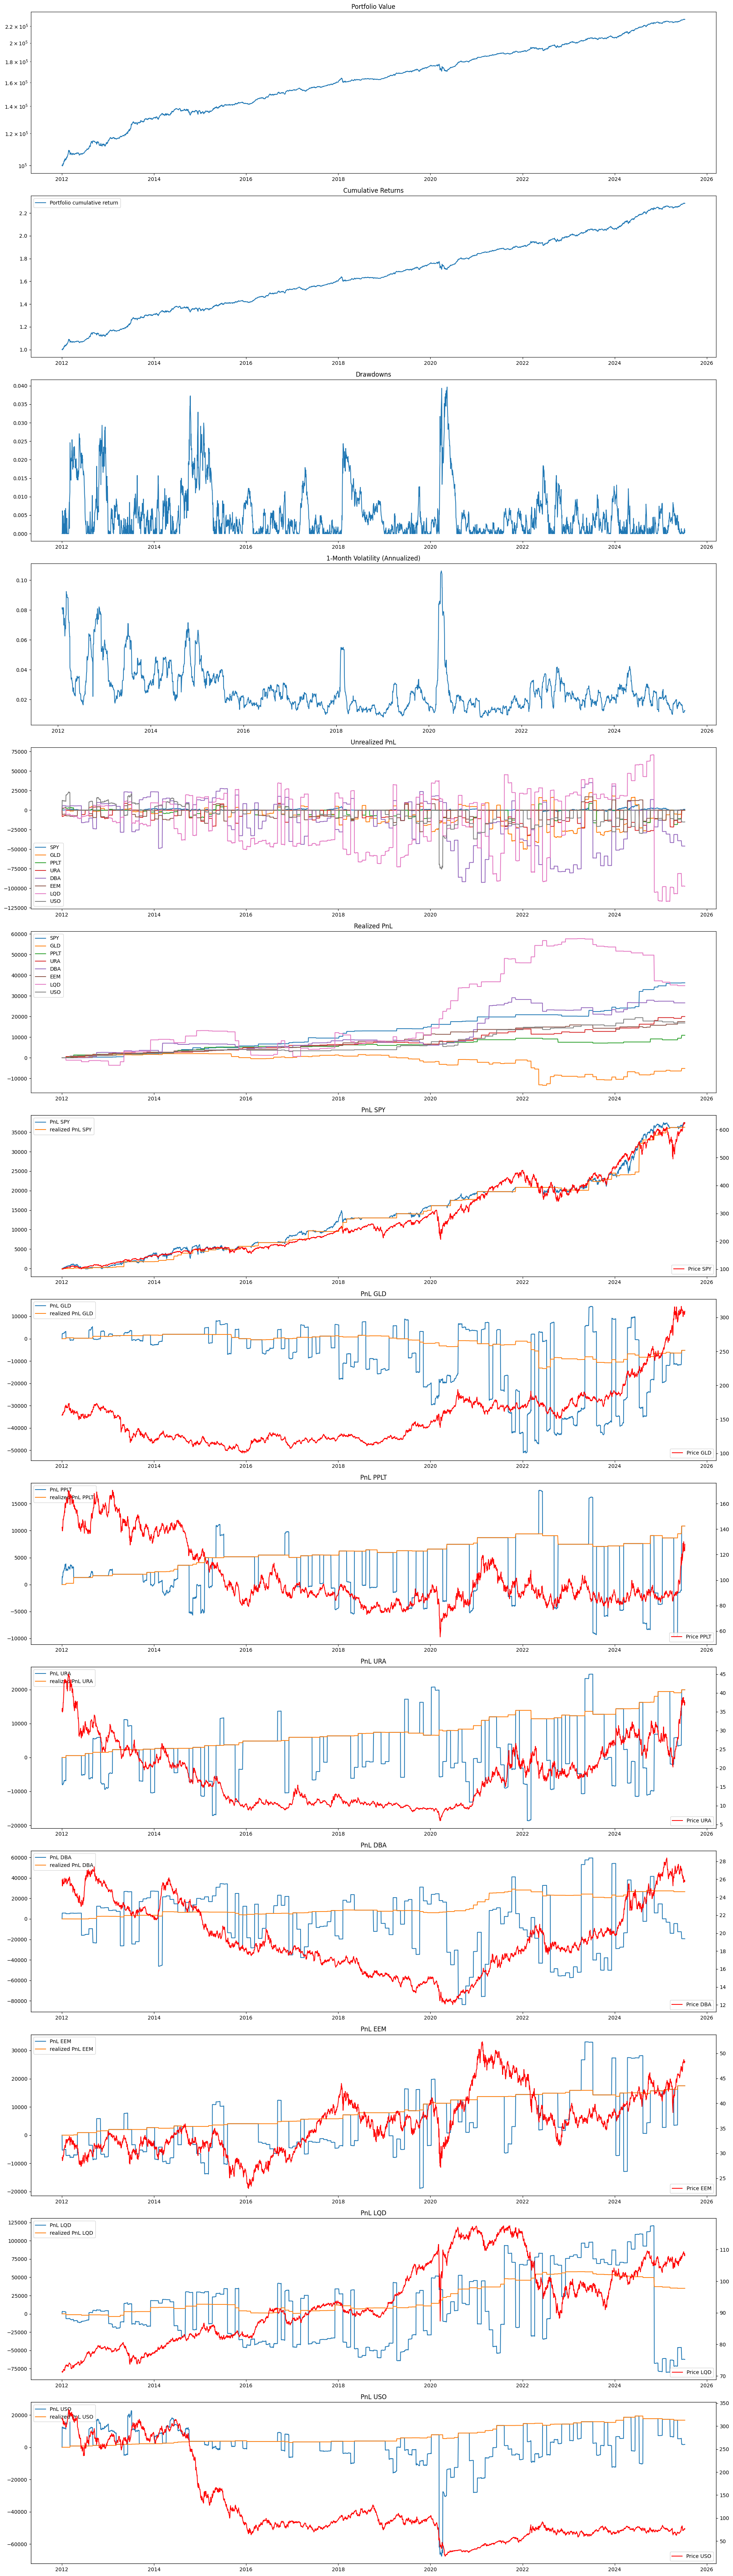

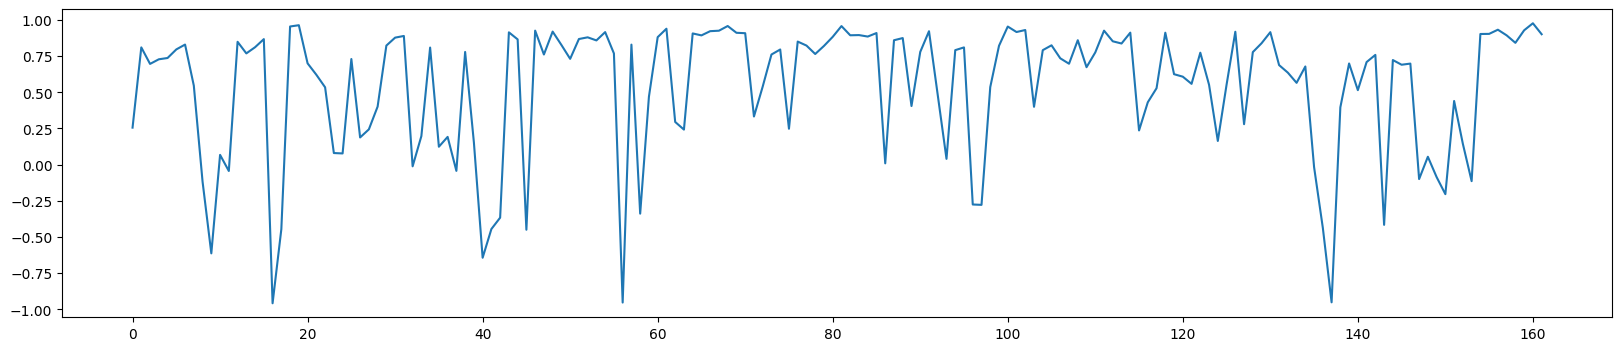

In [10]:
tickers_in_backtest = [
    'SPY', 
    # 'TLT', 
    'GLD', 
    'PPLT', 
    'URA', 
    'DBA', 
    'EEM',
    'LQD', 
    # 'IBIT',
    'USO',
]


ret_model_perf_tracker = []
vol_model_perf_tracker = []
leverage_tracker = []

# Price data
trading_price_data = {f: price_data[f].copy() for f in tickers_in_backtest}
start_date = pd.to_datetime('2012-01-01')
for ticker in trading_price_data:
    df = trading_price_data[ticker]
    df = df.loc[df.index >= start_date]
    trading_price_data[ticker] = df

# Trading data
trading_data = dict()
for ticker in tickers_in_backtest:
    trading_data[ticker] = risky_assets[ticker]['data']


btr = BackTester(trading_price_data)
btr.add_strategy(
    MultiAssetStrategy,
    tickers=tickers_in_backtest,
    price_data=trading_price_data,
    rebalance_period=rebalance_period,
    lookback_periods=lookback_periods,
    dict_data=trading_data.copy(),
    covariance_matrix_lookback=covariance_matrix_lookback,
    historical_period=historical_lookback_period,
)
results = btr.backtest()

for key in results:
    if key == 'returns': continue
    print(f"{key}: {results[key]:.2f}")

print(f'Mean leverage: {np.mean(leverage_tracker):.2f}')



btr.plot_results()

plt.figure(figsize=(20, 4))
plt.plot(leverage_tracker, label='Leverage')
plt.show()




## END

# LIVE TRADING

## Calculate Positions

SPY
vol_scaling_factor: 1.0


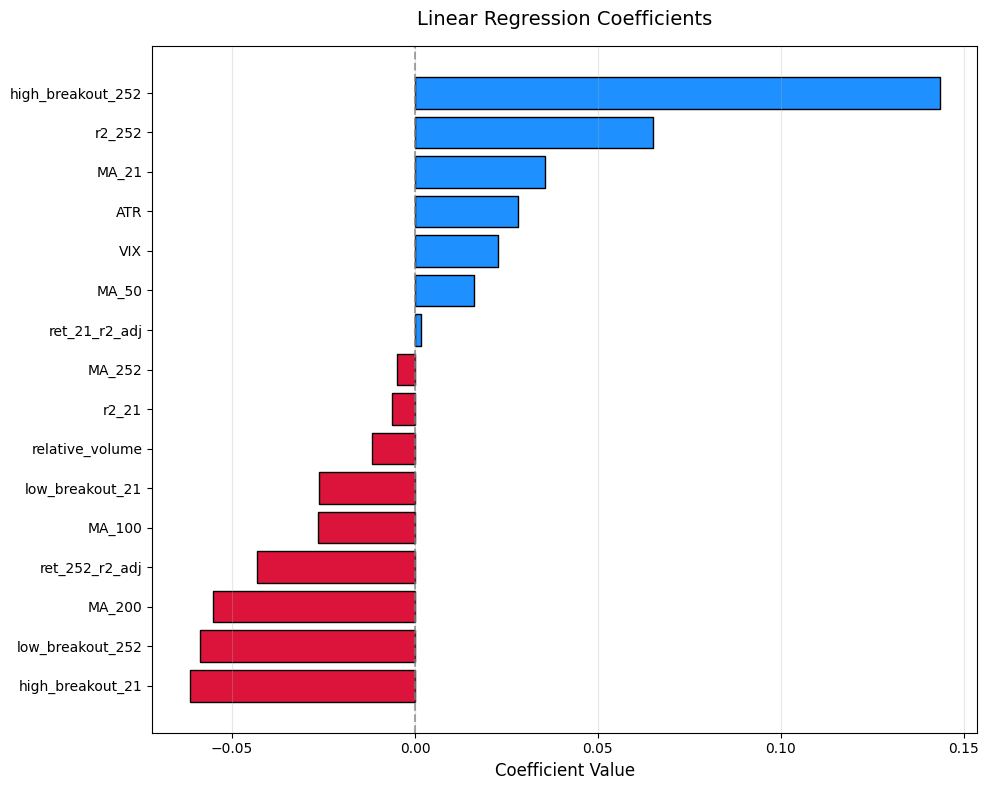

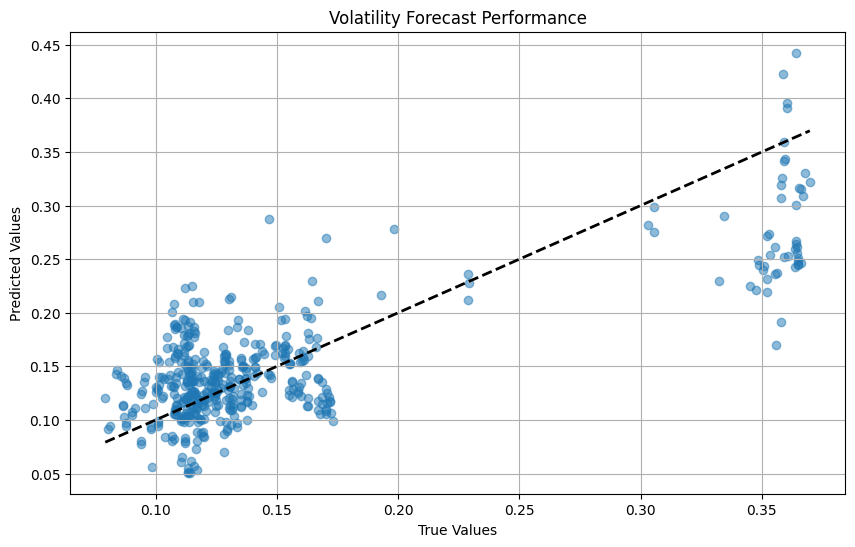

ret_scaling_factor: 0.1
scaling_factor: 0.316227766016838
GLD
vol_scaling_factor: 0.13053097345132736


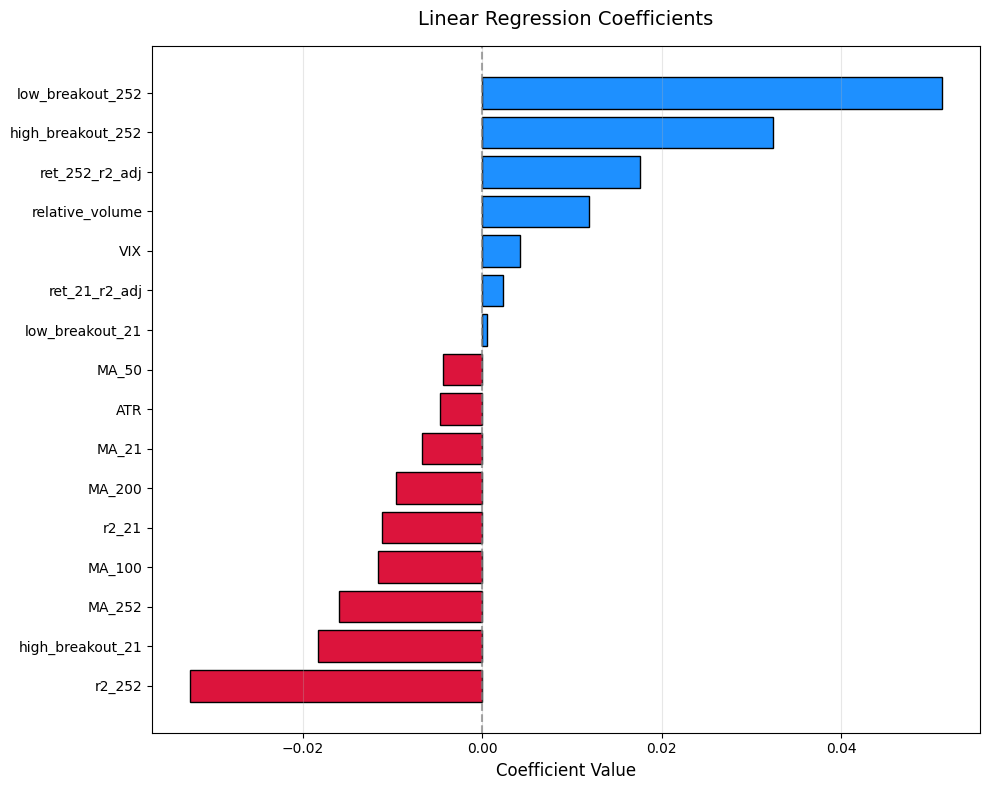

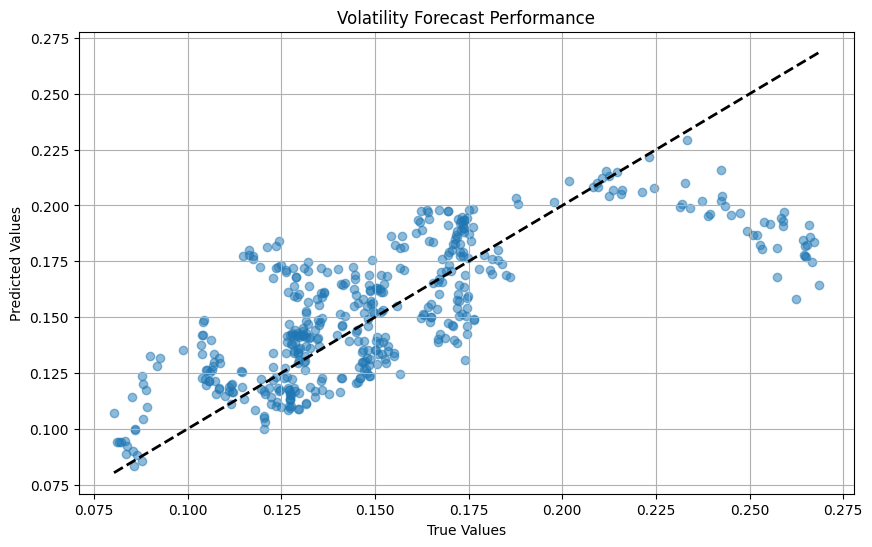

ret_scaling_factor: 0.1
scaling_factor: 0.11425015249500868
PPLT
vol_scaling_factor: 0.7350993377483444


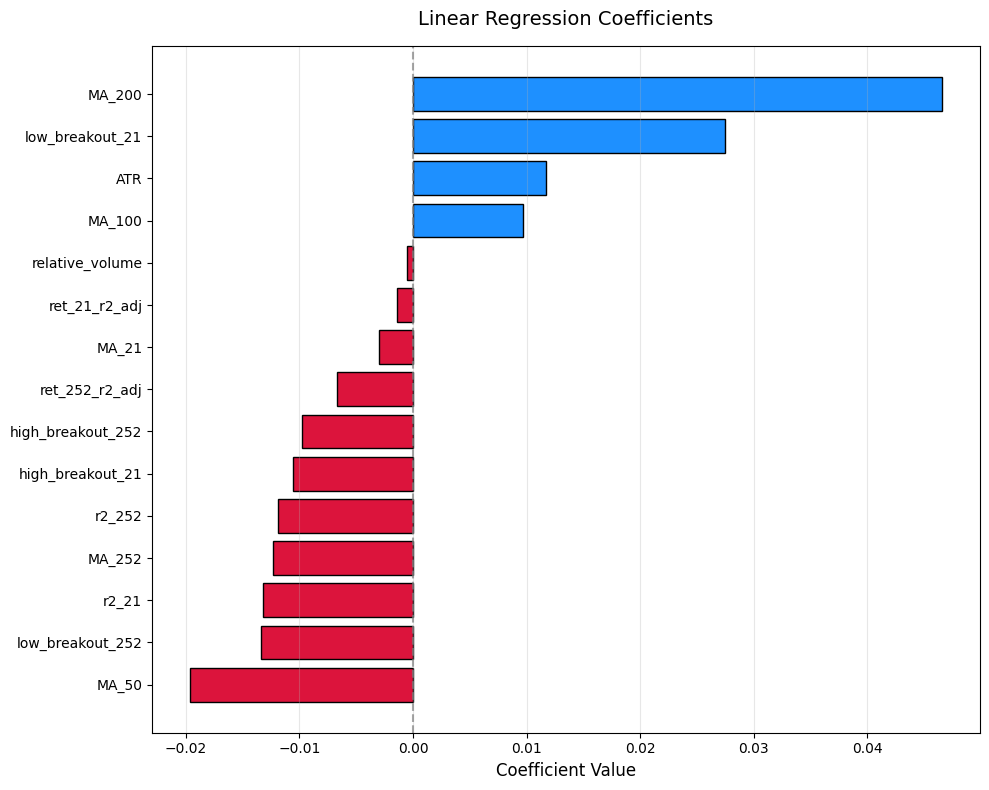

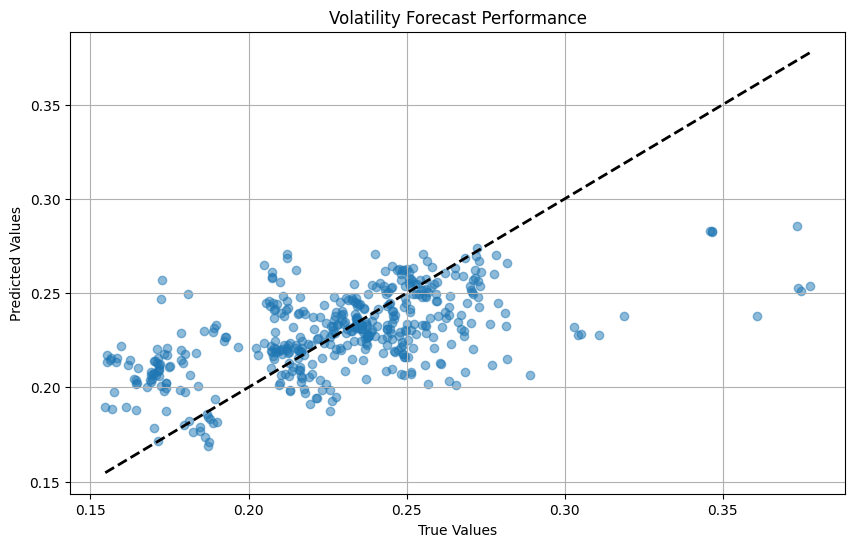

ret_scaling_factor: -0.01
scaling_factor: -0.08573793429680614
URA
vol_scaling_factor: 0.1


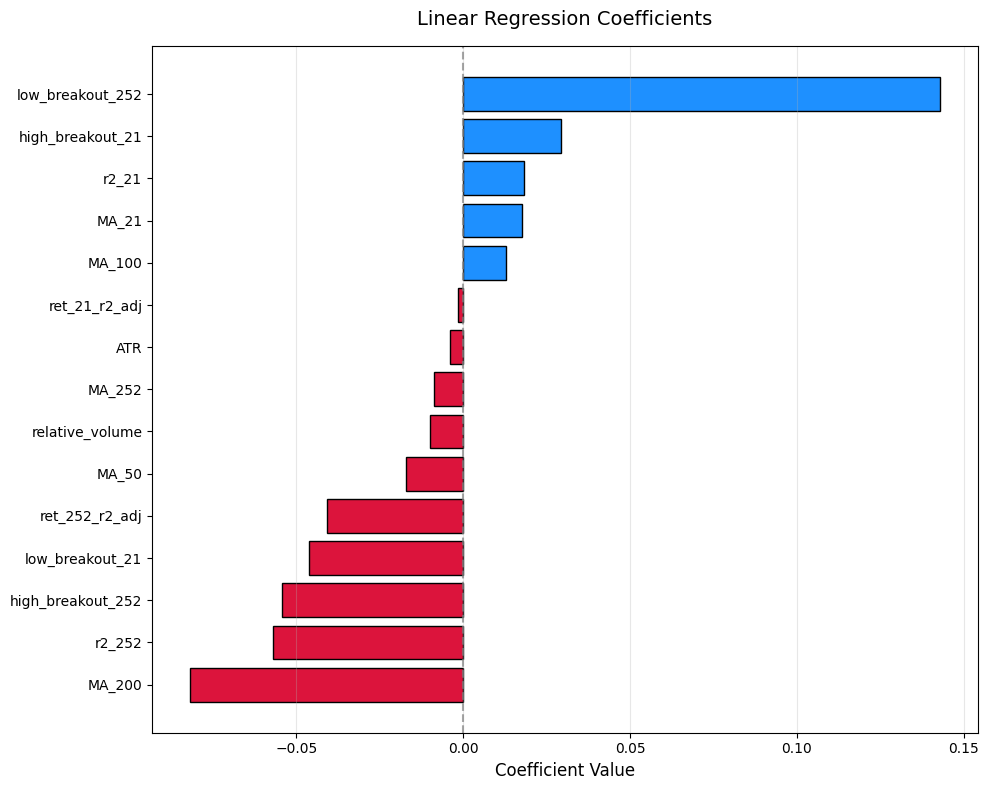

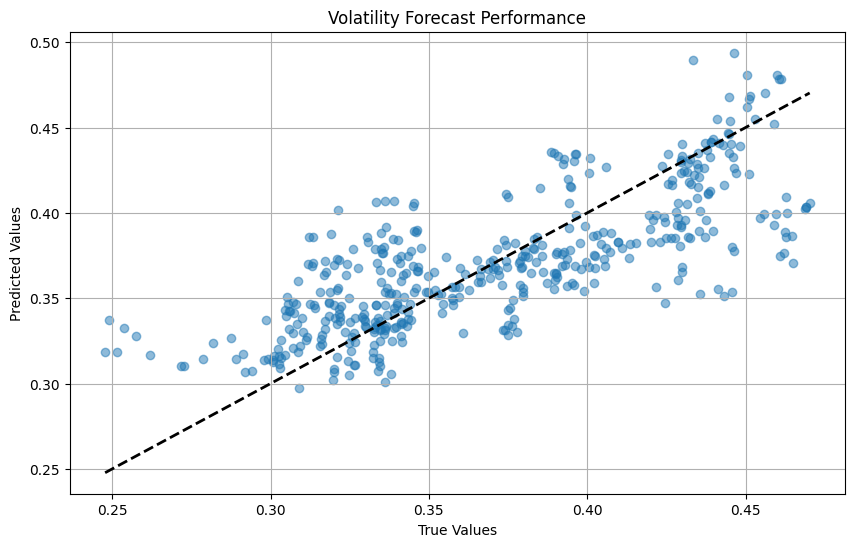

ret_scaling_factor: -0.01
scaling_factor: -0.0316227766016838
DBA
vol_scaling_factor: 0.9227373068432672


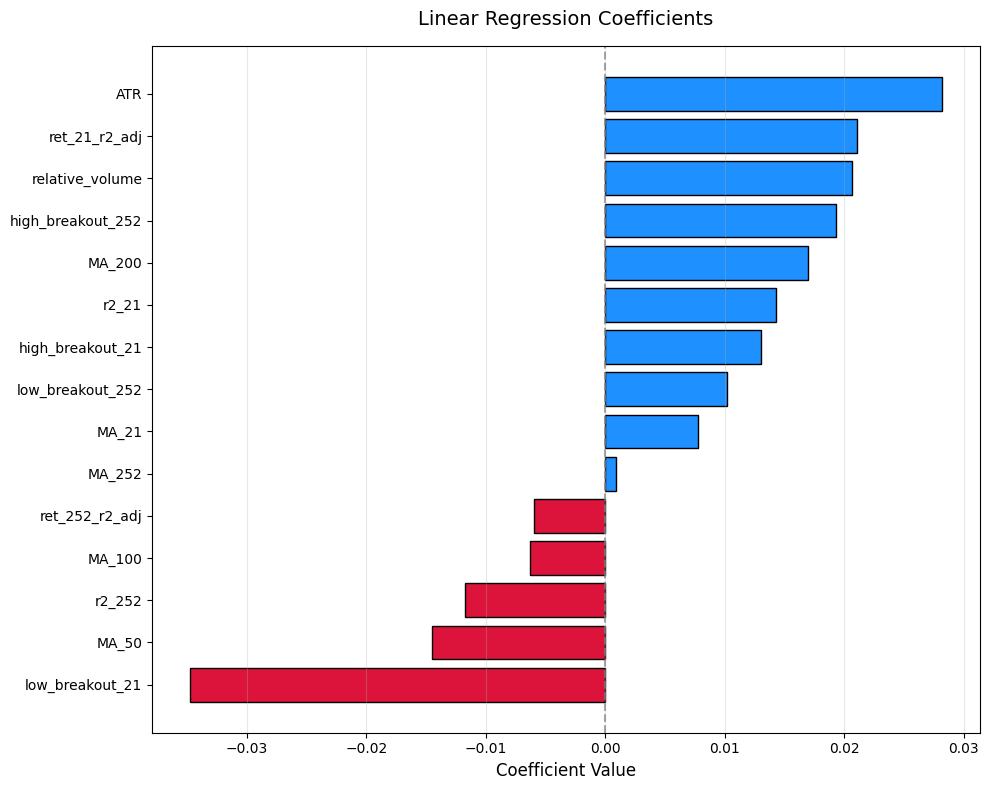

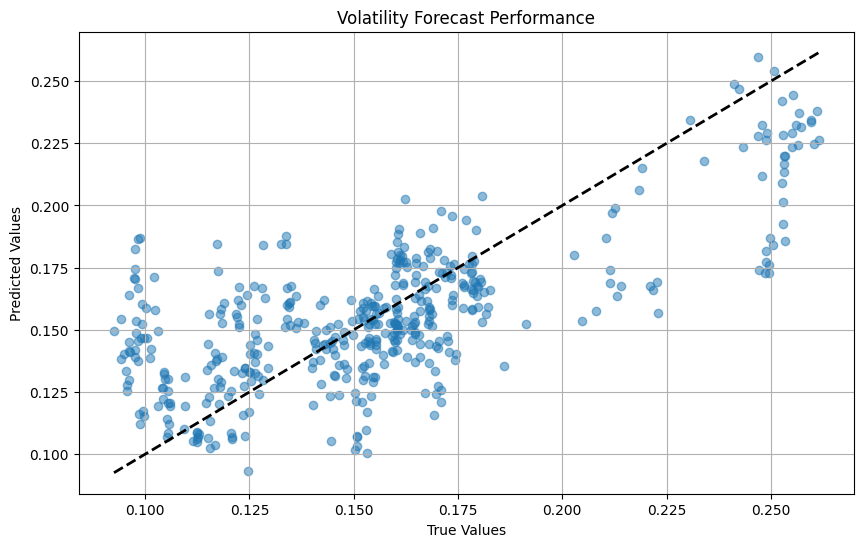

ret_scaling_factor: 0.2370364525310342
scaling_factor: 0.46767764307498005
EEM
vol_scaling_factor: 0.9448123620309051


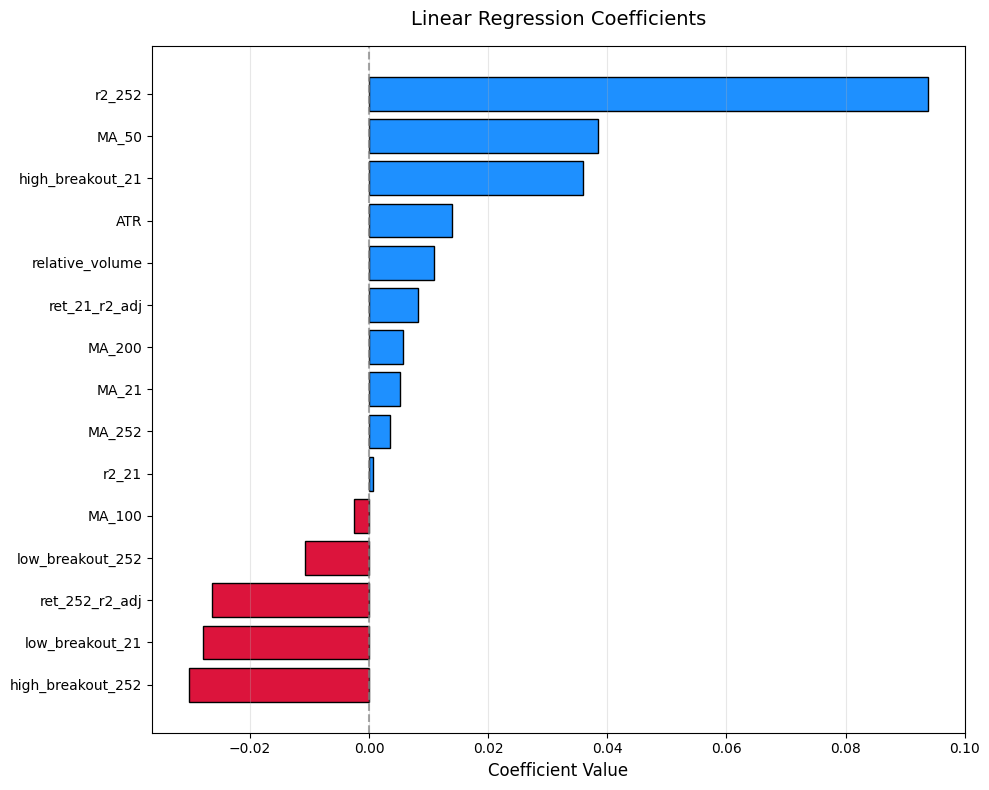

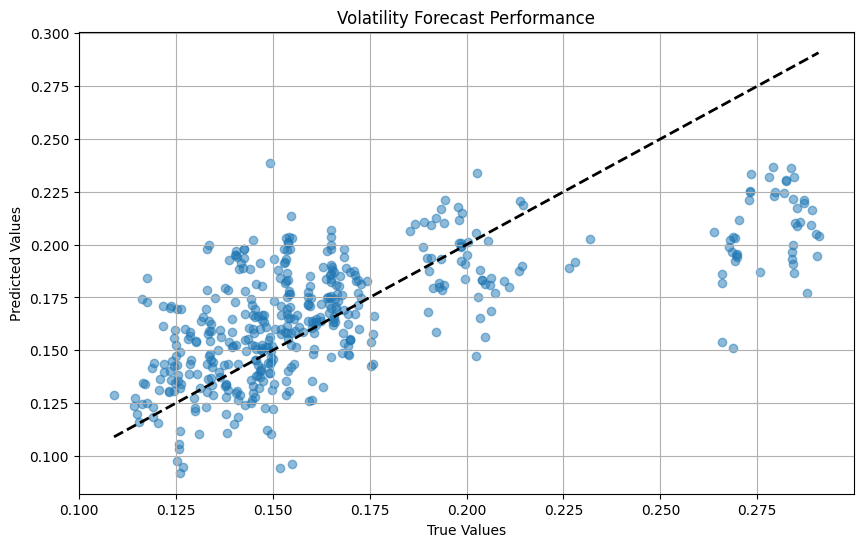

ret_scaling_factor: -0.01
scaling_factor: -0.09720145894125796
LQD
vol_scaling_factor: 0.3796909492273731


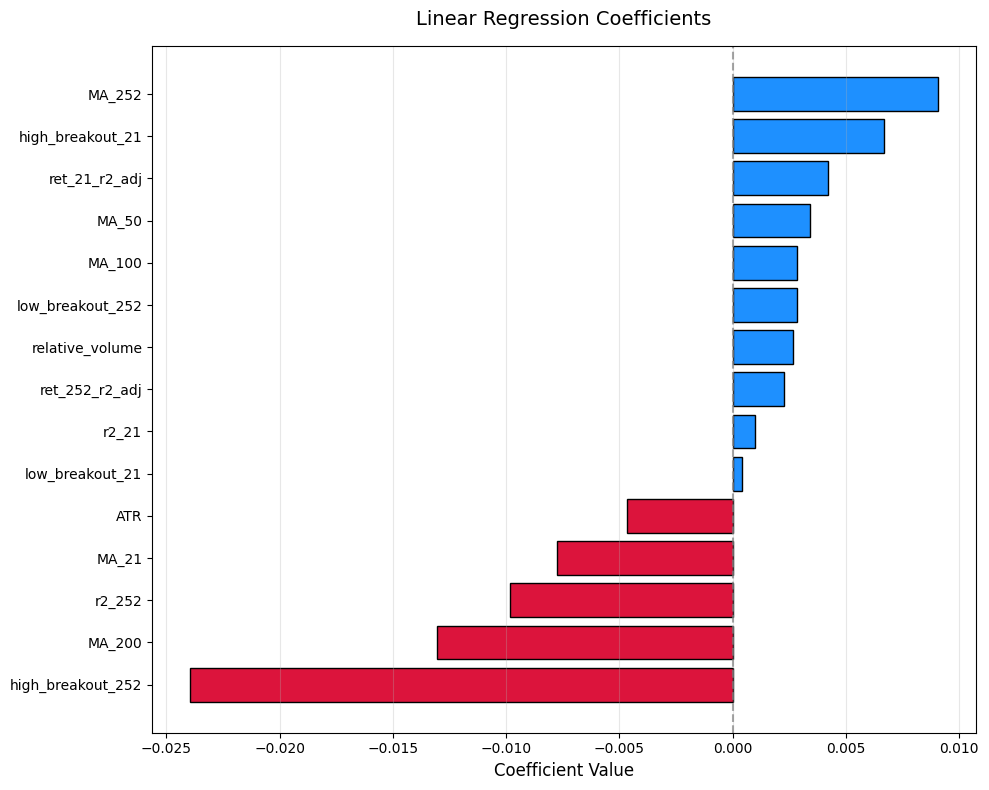

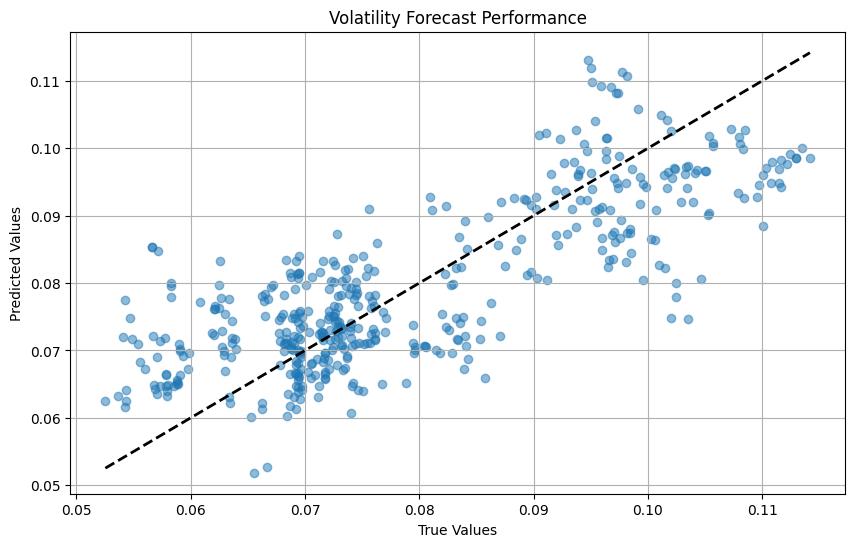

ret_scaling_factor: 0.1
scaling_factor: 0.19485660092164522
IBIT
vol_scaling_factor: 1.0


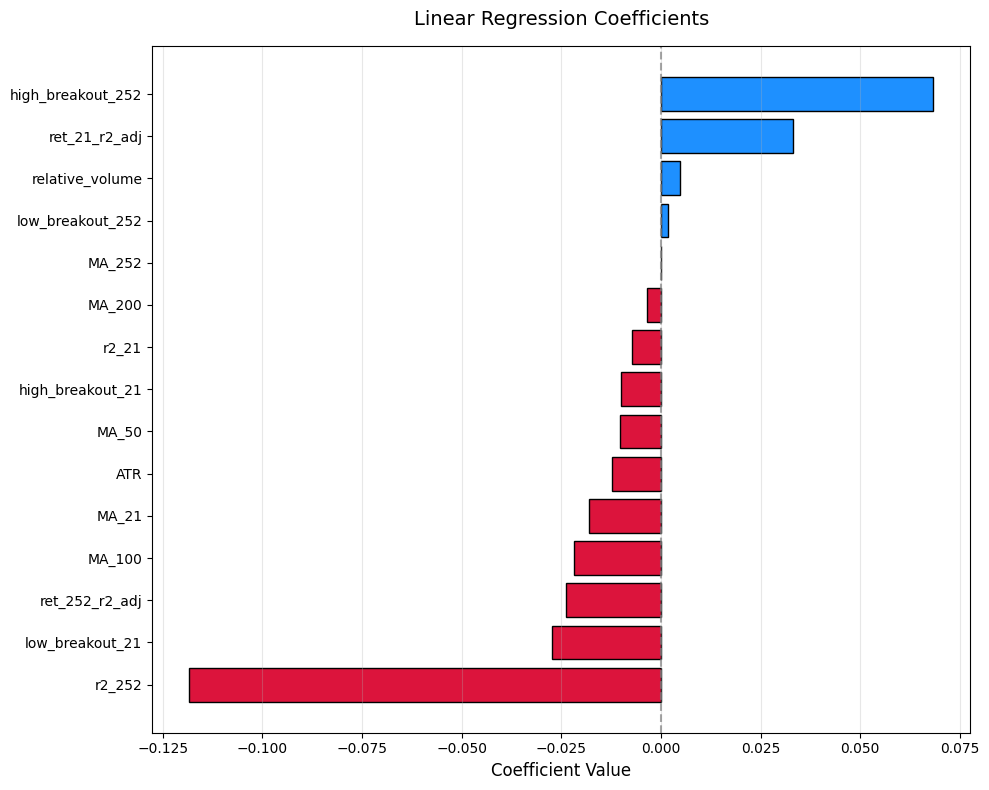

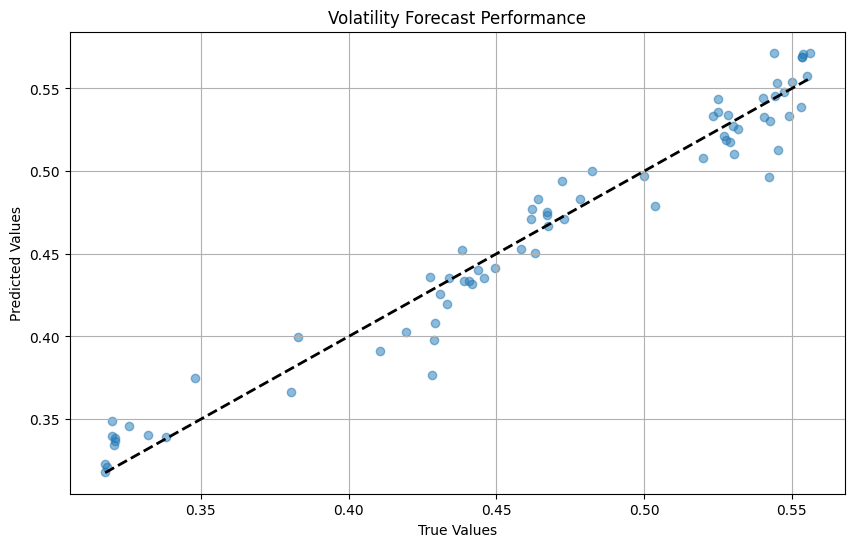

ret_scaling_factor: -0.01
scaling_factor: -0.10000000000000002
USO
vol_scaling_factor: 0.11037527593818997


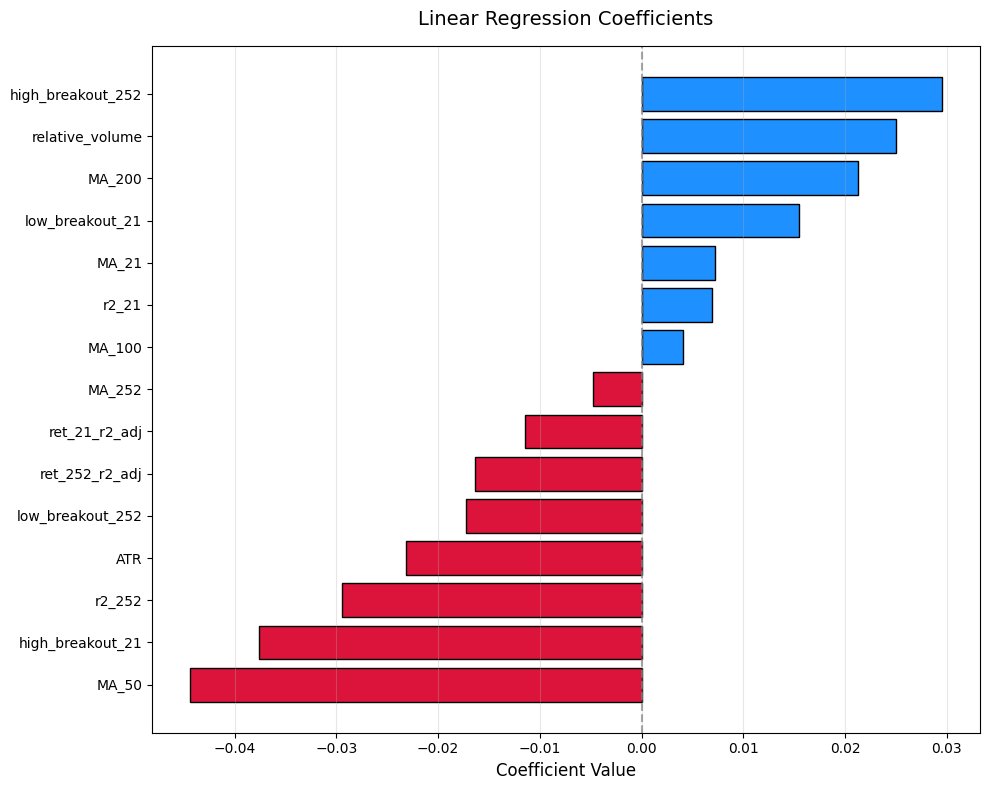

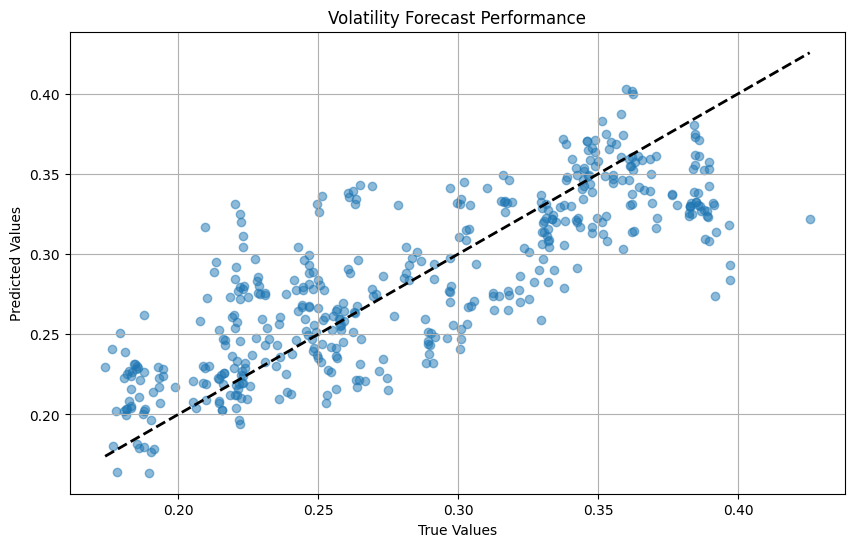

ret_scaling_factor: -0.01
scaling_factor: -0.0332227747092548
------------------------------------------------------------------------
SPY
Current date:           2025-07-11 00:00:00
Allocation:             8.33%
Capital allocated:     $9398.41
shares to buy:          15 = $9398.41 / $623.62
------------------------------------------------------------------------
GLD
Current date:           2025-07-11 00:00:00
Allocation:             0.00%
Capital allocated:     $0.00
shares to buy:          0 = $0.00 / $309.14
------------------------------------------------------------------------
PPLT
Current date:           2025-07-11 00:00:00
Allocation:             0.00%
Capital allocated:     $0.00
shares to buy:          0 = $0.00 / $128.20
------------------------------------------------------------------------
URA
Current date:           2025-07-11 00:00:00
Allocation:             0.00%
Capital allocated:     $0.00
shares to buy:          0 = $0.00 / $37.51
-----------------------------------

In [13]:
capital = 75211
leverage = 1.5
capital_spent = 0

ticker_list = [
    'SPY', 
    # 'TLT', 
    'GLD', 
    'PPLT', 
    'URA', 
    'DBA', 
    'EEM',
    'LQD', 
    'IBIT',
    'USO',
]

trading_data = {f: risky_assets[f]['data'] for f in ticker_list}


asset_allocation_weights = allocation_func(
    ticker_list=ticker_list, 
    lookback_periods=lookback_periods, 
    historical_period=historical_lookback_period, 
    current_date=current_date,
    dict_data=trading_data,
    covariance_matrix_lookback=covariance_matrix_lookback,
    verbose=True,
)




# ret_forecast_adjustment = dict()
# var_forecast_adjustment = dict()
sum_of_factors = 0
for ticker in ticker_list:
    print('------------------------------------------------------------------------')
    df_data = trading_data[ticker].copy()

    capital_allocated = capital * leverage * asset_allocation_weights[ticker]
    current_price = df_data.iloc[-1]['close']
    shares_to_buy = int(capital_allocated / current_price)
    capital_to_buy = shares_to_buy * current_price
    capital_spent += capital_to_buy


    print(ticker)
    print(f'Current date:           {df_data.index[-1]}')
    print(f'Allocation:             {asset_allocation_weights[ticker]:.2%}')
    print(f'Capital allocated:     ${capital_allocated:.2f}')
    print(f'shares to buy:          {shares_to_buy} = ${capital_allocated:.2f} / ${current_price:.2f}')

    sum_of_factors += asset_allocation_weights[ticker]


df_data = price_data['IB01.L'].copy()
print('------------------------------------------------------------------------')
capital_left = capital - capital_spent
cash_allocation = max(capital_left, 0)

print(f'IB01.L')
print(f'capital_left:           {capital_left:.2f} = {capital_left / capital:.2%}')
print(f'allocation:             {cash_allocation / capital:.2%}')
print(f'shares to buy:          {int(cash_allocation / df_data.iloc[-1]["close"]):.2f} = ${int(cash_allocation):.2f} / ${df_data.iloc[-1]["close"]:.2f}')
print('------------------------------------------------------------------------')

print(f'sum of factors: {sum_of_factors * leverage:.2%}')

# PORTFOLIO TRACKING

CAGR:                   12.20%
Volatility:             7.74%
Sharpe Ratio:           1.58
Max Drawdown:          -3.21%
Total Returns:          4.65%
Total PnL:             $3401.37


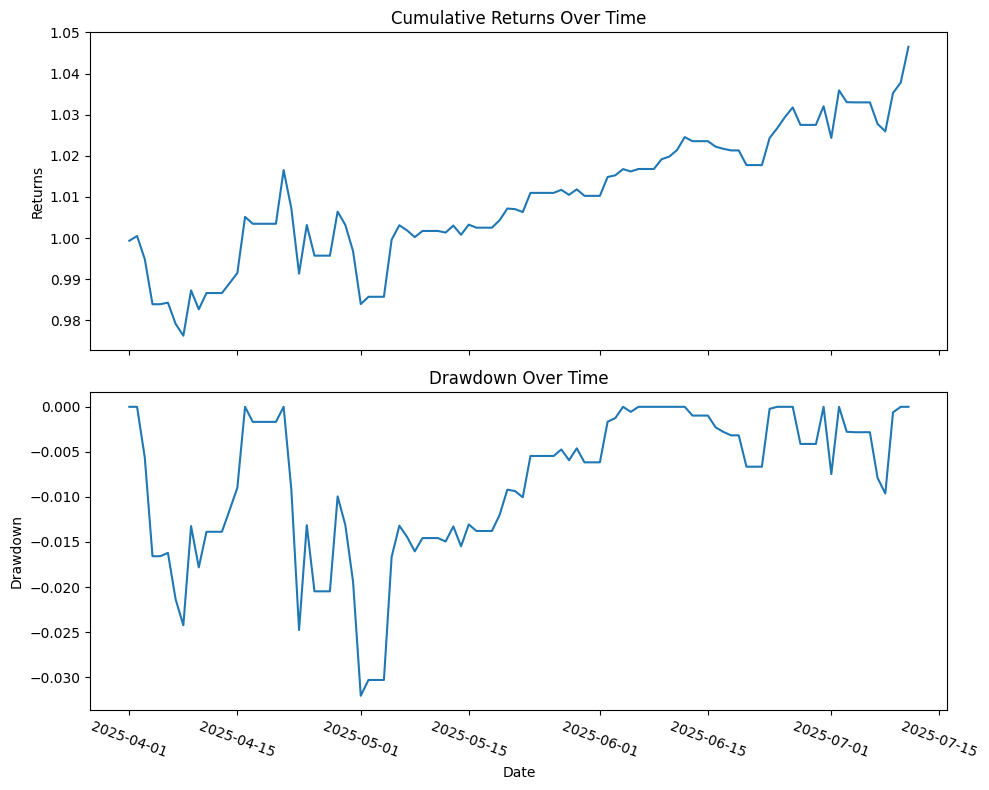

In [12]:
def compute_portfolio_value(trades_df, price_data_dict):
    """
    Compute daily portfolio value given trades and price data.
    
    trades_df: DataFrame with columns ['date', 'ticker', 'quantity', 'price', 'fees']
    price_data_dict: dict mapping ticker -> DataFrame with index 'date' and column 'close'
    
    Returns:
        portfolio_value: Series indexed by date
    """
    # Ensure date types and sort
    trades = trades_df.copy()
    trades['date'] = pd.to_datetime(trades['date'])
    trades.sort_values('date', inplace=True)

    # Determine date index range
    all_dates = pd.date_range(
        start=trades['date'].min(), 
        end=max(df.index.max() for df in price_data_dict.values()),
        freq='D'
    )
    
    # Initialize cash flow and holdings
    cash_flows = pd.Series(0.0, index=all_dates)
    holdings = {ticker: pd.Series(0.0, index=all_dates) for ticker in price_data_dict if ticker != 'CASH'}
    invested_capital = pd.Series(0.0, index=all_dates)
    
    # Process trades
    for _, row in trades.iterrows():
        dt = row['date']
        tk = row['ticker']
        qty = row['quantity']
        price = row['price']
        fees = row['fees']
        
        if tk == 'CASH':
            cash_flows.loc[dt] += qty
            invested_capital[dt:] += qty
        else:
            # Update holdings from this date onward
            holdings[tk].loc[dt:] += qty
            # Cash change: buying (positive qty) -> outflow; selling (negative qty) -> inflow
            cash_flows.loc[dt] += -qty * price - fees
    
    # Compute cumulative cash
    cash = cash_flows.cumsum()
    
    # Compute daily holdings value
    holdings_value = pd.Series(0.0, index=all_dates)
    for tk, pos in holdings.items():
        # Align prices
        # prices = price_data_dict[tk].reindex(all_dates)['close'].fillna(method='ffill')
        prices = price_data_dict[tk].reindex(all_dates)['close'].ffill()
        holdings_value += pos * prices
    
    # Total portfolio value
    portfolio_value = cash + holdings_value
    return portfolio_value, invested_capital

def compute_performance_metrics(portfolio_value, invested_capital, trading_days=252):
    """
    Compute performance metrics: CAGR, volatility, Sharpe ratio, max drawdown
    """
    cumulative_returns = portfolio_value / invested_capital

    # Daily returns
    daily_returns = cumulative_returns.pct_change().dropna()
    
    # CAGR
    total_days = (cumulative_returns.index[-1] - cumulative_returns.index[0]).days
    cagr = (cumulative_returns.iloc[-1] / cumulative_returns.iloc[0]) ** (trading_days / total_days) - 1
    
    # Volatility (annualized)
    vol = daily_returns.std() * np.sqrt(trading_days)
    
    # Sharpe ratio (assumes risk-free rate = 0)
    sharpe = cagr / vol
    
    # Max drawdown
    rolling_max = cumulative_returns.cummax()
    drawdown = (cumulative_returns - rolling_max) / rolling_max
    max_dd = drawdown.min()

    print(f'CAGR:                   {cagr:.2%}')
    print(f'Volatility:             {vol:.2%}')
    print(f'Sharpe Ratio:           {sharpe:.2f}')
    print(f'Max Drawdown:          -{-max_dd:.2%}')
    print(f'Total Returns:          {portfolio_value.iloc[-1] / invested_capital.iloc[-1] - 1:.2%}')
    print(f'Total PnL:             ${portfolio_value.iloc[-1] - invested_capital.iloc[-1]:.2f}')
    
    
    return {
        'CAGR': cagr,
        'Volatility': vol,
        'Sharpe Ratio': sharpe,
        'Max Drawdown': max_dd
    }

def plot_portfolio_and_drawdown(portfolio_value, invested_capital):
    """
    Plot portfolio value and drawdown
    """
    cumulative_returns = portfolio_value / invested_capital

    # Compute drawdown
    rolling_max = cumulative_returns.cummax()
    drawdown = (cumulative_returns - rolling_max) / rolling_max
    
    # Plot
    fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(10, 8))
    
    ax1.plot(cumulative_returns.index, cumulative_returns.values)
    ax1.set_title('Cumulative Returns Over Time')
    ax1.set_ylabel('Returns')
    
    ax2.plot(drawdown.index, drawdown.values)
    ax2.set_title('Drawdown Over Time')
    ax2.set_ylabel('Drawdown')
    ax2.set_xlabel('Date')
    plt.setp(ax2.get_xticklabels(), rotation=-20)
    
    plt.tight_layout()
    plt.show()

# Example usage:
trades_df = pd.read_excel('portfolio_tracker.xlsx')
# trades_df = trades_df.loc[trades_df['ticker'].isin(['SPY', 'TLT', 'GLD', 'SHV', 'CASH'])]
price_data_dict = {
    'SPY': pd.read_pickle(f'./data/raw/price/SPY_{current_date}.pkl'),
    'TLT': pd.read_pickle(f'./data/raw/price/TLT_{current_date}.pkl'),
    'GLD': pd.read_pickle(f'./data/raw/price/GLD_{current_date}.pkl'),
    'SHV': pd.read_pickle(f'./data/raw/price/SHV_{current_date}.pkl'),
    'PPLT': pd.read_pickle(f'./data/raw/price/PPLT_{current_date}.pkl'),
    'URA': pd.read_pickle(f'./data/raw/price/URA_{current_date}.pkl'),
    'USO': pd.read_pickle(f'./data/raw/price/USO_{current_date}.pkl'),
    'IBIT': pd.read_pickle(f'./data/raw/price/IBIT_{current_date}.pkl'),
    'EEM': pd.read_pickle(f'./data/raw/price/EEM_{current_date}.pkl'),
    'DBA': pd.read_pickle(f'./data/raw/price/DBA_{current_date}.pkl'),
    'IB01.L': pd.read_pickle(f'./data/raw/price/IB01.L_{current_date}.pkl'),
    'LQD': pd.read_pickle(f'./data/raw/price/LQD_{current_date}.pkl'),

}
port_val, invested_cap = compute_portfolio_value(trades_df, price_data_dict)
metrics = compute_performance_metrics(port_val, invested_cap)
plot_portfolio_and_drawdown(port_val, invested_cap)
# for key in metrics:
#     print(f'{key}: {metrics[key]:.2f}')


